<div dir="rtl" lang="fa" align="right" style="direction: rtl; text-align: right;">

# هفته ۱۱ — تمرین کلاسی: پایپ‌لاین کارآموز 

> **سناریو:** از یک کارآموز جدید در PixelWorks AI خواسته شده یک پایپ‌لاین کامل از ابتدا تا انتها بسازد که همه‌ی چیزهایی را که تیم در این ترم یاد گرفته به کار بگیرد: افزایش داده (Augmentation)، بلوک باقیمانده (Residual Block)، آموزش درست با درنظرگرفتن BatchNorm و یادگیری انتقالی (Transfer Learning). کد او بدون خطا اجرا می‌شود، اما مدیرش هنوز مشکوک است: *«پایپ‌لاین اول معمولاً یک جای کارش می‌لنگد. قبل از اینکه منتشرش کنیم، ایرادش را پیدا کنید.»*

## نمای کلی جلسه

- **مدت زمان:** حدود ۲ ساعت
- **دیتاست:** دقیقاً همان دیتاست جانشین ۴کلاسه‌ی CIFAR-10 از تمرین قبلی (`automobile`، `ship`، `truck`، `airplane`) که تصاویر آن به `224×224` تغییر اندازه داده شده‌اند. امروز دیتاست جدیدی لازم نیست بارگذاری کنید؛ تمام زمان آماده‌سازی را صرف بررسی ایرادها کنید.
- **ساختار جلسه:** **چهار بررسی کوتاه**، هر کدام مربوط به یکی از موضوعات اصلی  . در هر بررسی بخشی از کد واقعی و ایراددار کارآموز را می‌بینید. ابتدا باید با دانسته‌های قبلی پیش‌بینی یا تشخیص دهید مشکل چیست، بعد آن را اصلاح کنید و در نهایت با یک عدد، assertion یا مقایسه ثابت کنید که اصلاح واقعاً درست بوده است؛ نه اینکه فقط «به نظر برسد درست شده».

| # | بررسی | موضوع مرورشده |
|---|---|---|
| 1 | آیا این Augmentation واقع‌بینانه است؟ | جلسات ۱–۲ (Augmentation) |
| 2 | آیا این واقعاً یک Residual Block است؟ | جلسه ۳ (ResNet) |
| 3 | چرا هر بار دقت را بررسی می‌کنم تغییر می‌کند؟ | مینی‌درس BatchNorm |
| 4 | چرا این مدل اصلاً چیزی یاد نمی‌گیرد؟ | جلسه ۴ (Pretrained / Feature Extraction) |

هر بررسی مستقل است. اگر گروه‌تان روی یکی از بخش‌ها گیر کرد، فعلاً از آن عبور کنید و در پایان برگردید. ۱۵ دقیقه‌ی آخر برای یک سؤال جمع‌بندی است که هر چهار موضوع را به هم مرتبط می‌کند.

## مواردی که باید تحویل دهید

- [ ] هر چهار ایراد را پیدا، توضیح و اصلاح کنید
- [ ] برای هر اصلاح یک بررسی قابل اندازه‌گیری ارائه دهید؛ فقط «الان اجرا می‌شود» کافی نیست و باید با عدد، assertion یا مقایسه ثابت کنید که مشکل حل شده است
- [ ] به سؤال رتبه‌بندی و جمع‌بندی نهایی در بخش ۵ پاسخ دهید

</div>


<div dir="rtl" lang="fa" align="right" style="direction: rtl; text-align: right;">

---
# بخش ۰ — آماده‌سازی (حدود ۱۰ دقیقه، مطلب جدیدی ندارد)

این دقیقاً همان دیتاست و پیش‌پردازش جلسه‌ی قبل است. سلول‌ها را اجرا کنید و ادامه دهید.

</div>


In [2]:
from pathlib import Path
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights

SEED = 42

# DATA_ROOT = Path("../darsname/data") # for m.azim
DATA_ROOT = Path("data")


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True #قطعی کردن الگوریتم
    torch.backends.cudnn.benchmark = False  #دنبال الگورینم های دیگه نگرده 


set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGENET_MEAN = [0.485, 0.456, 0.406]    #dataset imagenet
IMAGENET_STD = [0.229, 0.224, 0.225]
print(f"Using device: {DEVICE}")

Using device: cpu


In [3]:
def make_balanced_indices(targets, class_ids, n_per_class, seed=SEED):
    rng = random.Random(seed)
    targets = list(targets)
    chosen = []
    for c in class_ids:
        idx_c = [i for i, t in enumerate(targets) if t == c]
        rng.shuffle(idx_c)
        chosen.extend(idx_c[:n_per_class])
    rng.shuffle(chosen)
    return chosen


def make_val_test_split(targets, class_ids, n_val, n_test, seed=SEED):
    rng = random.Random(seed)
    targets = list(targets)
    val_indices, test_indices = [], []
    for c in class_ids:
        idx_c = [i for i, t in enumerate(targets) if t == c]
        rng.shuffle(idx_c)
        val_indices.extend(idx_c[:n_val])
        test_indices.extend(idx_c[n_val:n_val + n_test])
    rng.shuffle(val_indices)
    rng.shuffle(test_indices)
    return val_indices, test_indices


class TransformSubset(Dataset):
    def __init__(self, base_dataset, indices, transform, label_map=None):
        self.base_dataset = base_dataset
        self.indices = indices
        self.transform = transform
        self.label_map = label_map

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, label = self.base_dataset[self.indices[idx]]
        if self.label_map is not None:
            label = self.label_map[label]
        return self.transform(image), label


raw_train_full = datasets.CIFAR10(root=DATA_ROOT, train=True, download=True, transform=None)
raw_test_full = datasets.CIFAR10(root=DATA_ROOT, train=False, download=True, transform=None)

project_classes = ["automobile", "ship", "truck", "airplane"]
project_class_ids = [raw_train_full.classes.index(c) for c in project_classes]
project_label_map = {orig: i for i, orig in enumerate(project_class_ids)}

train_indices = make_balanced_indices(raw_train_full.targets, project_class_ids, n_per_class=40, seed=SEED)
val_indices, test_indices = make_val_test_split(raw_test_full.targets, project_class_ids, n_val=20, n_test=20, seed=SEED)

deterministic_transform = transforms.Compose([      # for val and test
    transforms.Resize((224, 224)),
    transforms.ToTensor(), # 0-255 -> 0-1
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), # for mean and std = [0.5,0.5,0.5],[0.5,0.5,0.5] ->   [-1,1]      (pixel-mean)/std
])

val_dataset = TransformSubset(raw_test_full, val_indices, deterministic_transform, label_map=project_label_map)
class_names = project_classes
NUM_CLASSES = len(class_names)
print("Classes:", class_names, "| Val images:", len(val_dataset))

Classes: ['automobile', 'ship', 'truck', 'airplane'] | Val images: 80


<div dir="rtl" lang="fa" align="right" style="direction: rtl; text-align: right;">

---
# بررسی ۱ — آیا این Augmentation واقع‌بینانه است؟ (حدود ۲۰ دقیقه)

**مرور:** جلسات ۱–۲ (حفظ برچسب، واقع‌گرایی و ارتباط با شرایط واقعی استفاده)

یادداشت کارآموز: *«برای مقاوم‌تر شدن مدل، چند نوع Augmentation را فعال کردم. آموزش هم بدون مشکل اجرا می‌شود.»*

</div>


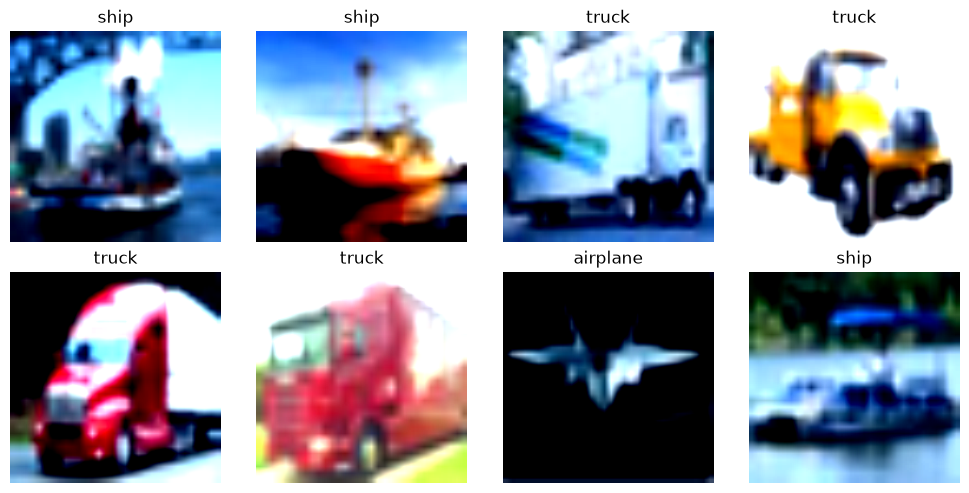

In [4]:
import numpy 
def denormalize(image_tensor):
    return image_tensor * 0.5 + 0.5


train_loader = DataLoader(val_dataset, batch_size=16, shuffle=True, num_workers=0)
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for image, label, axis in zip(images[:8], labels[:8], axes.flat):
    # TODO: denormalize `image`, permute to (H, W, C), clamp to [0, 1], imshow it
    denormalized_image = denormalize(image)
    image = denormalized_image.permute(1,2,0)
    image = image.clamp(min = 0,max=1)
    image_np = image.numpy()
    axis.imshow(image_np)
    axis.set_title(class_names[label.item()])
    # TODO: set the title to class_names[label.item()]
    axis.axis("off")

plt.tight_layout()
plt.show()

In [5]:
intern_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    #transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation([5,15]),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset_intern = TransformSubset(raw_train_full, train_indices, intern_train_transform, label_map=project_label_map)

using vertical flip would change the lables


<div dir="rtl" lang="fa" align="right" style="direction: rtl; text-align: right;">

**TODO:** قبل از اینکه چیزی بنویسید، شواهد را ببینید. با استفاده از `intern_train_transform`، از یک تصویر آموزشی دلخواه (هر اندیسی که خواستید) ۶ نسخه‌ی Augmented بسازید و نمایش دهید.

</div>


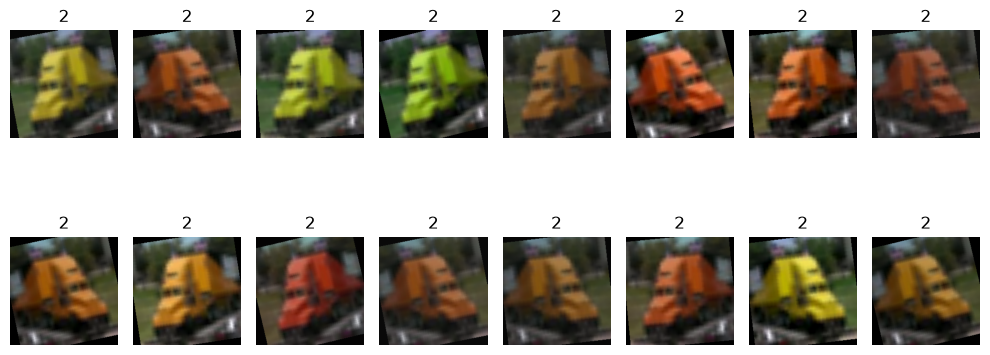

In [6]:

import numpy 
import matplotlib.pyplot as plt
# def denormalize(image_tensor):
#     return image_tensor * 0.5 + 0.5
def denormalize(image_tensor):
    return image_tensor * torch.tensor(IMAGENET_STD).view(3, 1, 1) + torch.tensor(IMAGENET_MEAN).view(3, 1, 1)

sample_index = 0

images, labels =train_dataset_intern[sample_index]

fig, axes = plt.subplots(2, 8, figsize=(10, 5))
for axis in axes.flat:
    image, label =train_dataset_intern[sample_index]
    denormalized_image = denormalize(image)
    image = denormalized_image.permute(1,2,0)
    image = image.clamp(min = 0,max=1)
    axis.imshow(image)
    axis.set_title(label)
    # TODO: set the title to class_names[label.item()]
    axis.axis("off")

plt.tight_layout()
plt.show()
# TODO: fetch train_dataset_intern[0] six times (each call re-samples the randomness),
#       denormalize + permute + clamp each result, and plot all 6 in a row

<div dir="rtl" lang="fa" align="right" style="direction: rtl; text-align: right;">

**Q1.1:** هیچ‌کدام از این خط‌ها باعث crash نمی‌شوند و از نظر برنامه‌نویسی هم اشتباه نیستند؛ همه‌ی آن‌ها کد معتبر و قابل اجرای PyTorch هستند. ایراد اینجا یک **اشتباه طراحی** است. در `intern_train_transform` کدام transform را حذف یا علامت‌گذاری می‌کنید و چرا؟ پاسخ را با همان سه معیار تمرین Augmentation توضیح دهید: **حفظ برچسب (label preservation)**، **واقع‌گرایی (realism)** و **ارتباط با شرایط واقعی استفاده (deployment relevance)**. حتماً پاسخ را مشخصاً برای همین چهار کلاس (`automobile`، `ship`، `truck`، `airplane`) توضیح دهید؛ چون تبدیلی که برای یک دیتاست مناسب است ممکن است برای دیتاست دیگری نامناسب باشد.

> **پاسخ گروه:**

**TODO:** یک `corrected_train_transform` بسازید که دقیقاً همان پایپ‌لاین قبلی باشد، فقط همان transformی که گروه‌تان نامناسب تشخیص داده حذف شده باشد.

</div>


In [7]:
# TODO: 
corrected_train_transform = transforms.Compose([
    transforms.Resize((224, 224)), #consider smaller images will have low quality
    #transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation([5,15]),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

<div dir="rtl" lang="fa" align="right" style="direction: rtl; text-align: right;">

**Q1.2 (بررسی سریع، بدون نیاز به آموزش مدل):** برای «اثبات» این اصلاح لازم نیست مدل را آموزش دهید؛ شواهد را قبلاً در شبکه‌ی ۶تصویری دیده‌اید. در یک جمله بگویید انتظار دارید شبکه‌ی ۶تصویری ساخته‌شده با `corrected_train_transform` نسبت به `intern_train_transform` چه تفاوتی داشته باشد. سپس آن را واقعاً رسم کنید و بررسی کنید که پیش‌بینی‌تان درست بوده است.

> **پاسخ گروه:**

</div>


In [8]:
# TODO: repeat the 6-view visualization using corrected_train_transform

<div dir="rtl" lang="fa" align="right" style="direction: rtl; text-align: right;">

---
# بررسی ۲ — آیا این واقعاً یک Residual Block است؟ (حدود ۲۵ دقیقه)

**مرور:** جلسه ۳ (معادله‌ی اصلی و تعریف‌کننده‌ی یادگیری باقیمانده / Residual Learning)

یادداشت کارآموز: *«بلوک Residual را طبق شکل ساختم. ابعاد همه درست‌اند و هیچ خطایی هم ندارم.»*

</div>


In [9]:
class InternResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        # identity = self.shortcut(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        # out = out + identity    # جلوگیری از vanishing
        out = self.relu(out)
        return out


test_block = InternResidualBlock(in_channels=64, out_channels=64, stride=1) 
test_input = torch.randn(2, 64, 56, 56) # 224 ->(7*7) 112 ->(maxpool) ->56
test_output = test_block(test_input)
print("Input shape: ", tuple(test_input.shape))
print("Output shape:", tuple(test_output.shape))
print("No errors, shapes match. Ship it?")

Input shape:  (2, 64, 56, 56)
Output shape: (2, 64, 56, 56)
No errors, shapes match. Ship it?


<div dir="rtl" lang="fa" align="right" style="direction: rtl; text-align: right;">

**Q2.1 (ابعاد گول‌تان زده‌اند):** سلول بالا را اجرا کنید. شکل تنسورها کاملاً با هم سازگار است؛ حتی `self.shortcut` هم در `__init__` تعریف شده و وجود دارد. با این حال، این کد **یک Residual Block واقعی نیست**. متد `forward` را خط‌به‌خط بررسی کنید و دقیقاً مشخص کنید چه چیزی جا افتاده است. اصلاح لازم را در یک خط بنویسید.

> **پاسخ گروه:**
        out = out + identity    # جلوگیری از vanishing

**TODO:** متد `InternResidualBlock.forward` را در سلول پایین اصلاح کنید. کلاس را کپی کنید و فقط متد `forward` را تغییر دهید.

</div>


In [10]:
class FixedResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        # TODO: implement the correct forward pass:
        #   out = conv1 -> bn1 -> relu -> conv2 -> bn2
        #   identity = self.shortcut(x)
        #   return relu(out + identity)
        
        identity = self.shortcut(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = out + identity    # جلوگیری از vanishing
        out = self.relu(out)
        return out
    
        # raise NotImplementedError

<div dir="rtl" lang="fa" align="right" style="direction: rtl; text-align: right;">

## با یک تست ثابتش کنید، نه با یک دور آموزش کامل

برای پیدا کردن این ایراد لازم نیست یک شبکه‌ی کامل را آموزش دهید؛ یک بررسی دوخطی می‌توانست همان موقع در code review مشکل را آشکار کند. **TODO:** یک assertion بنویسید که بتواند یک Residual Block واقعی را از `InternResidualBlock` تشخیص دهد. به‌طور مشخص: هر دو بلوک را با **وزن‌های کاملاً یکسان** بسازید (با استفاده از `state_dict()` وزن‌های `intern_block` را داخل بلوک اصلاح‌شده کپی کنید تا هر تفاوتی در خروجی فقط به ساختار مربوط باشد، نه مقداردهی اولیه‌ی تصادفی)، سپس به هر دو **دقیقاً یک ورودی یکسان** بدهید و بررسی کنید آیا خروجی‌هایشان متفاوت است یا نه.

</div>


In [11]:
set_seed(0)
intern_block = InternResidualBlock(in_channels=32, out_channels=32, stride=1)
fixed_block = FixedResidualBlock(in_channels=32, out_channels=32, stride=1)

fixed_block.load_state_dict(intern_block.state_dict())  # force identical weights

probe_input = torch.randn(1, 32, 16, 16)

# TODO: buggy_output = intern_block(probe_input)
# TODO: fixed_output = fixed_block(probe_input)
# TODO: assert NOT torch.allclose(buggy_output, fixed_output), "these should differ!"
# TODO: print how large the difference is, e.g. (fixed_output - buggy_output).abs().mean()

buggy_output = intern_block(probe_input)
fixed_output = fixed_block(probe_input)

assert not torch.allclose(buggy_output, fixed_output)
print ((fixed_output - buggy_output).abs().mean())
print("If this cell runs without an AssertionError, your fix changes the block's behavior.")

tensor(0.3989, grad_fn=<MeanBackward0>)
If this cell runs without an AssertionError, your fix changes the block's behavior.


<div dir="rtl" lang="fa" align="right" style="direction: rtl; text-align: right;">

**Q2.2:** با اینکه وزن‌ها و ورودی هر دو بلوک کاملاً یکسان‌اند، خروجی‌ها همچنان با هم فرق دارند. در یک جمله توضیح دهید چرا این نوع تست — «وزن یکسان، ورودی یکسان، مقایسه‌ی خروجی» — نسبت به این‌که فقط بگوییم «کد اجرا می‌شود و ابعاد درست‌اند» بررسی قوی‌تری است و در آینده هم می‌تواند ایرادهای ساختاریِ دیگری را که به شکل تنسورها مربوط نیستند پیدا کند.

> **پاسخ گروه:**
وزن‌ها و ورودی هر دو بلوک کاملاً یکسان‌ میشود تا بررسی کند ایا خروجی متفاوت میشود یا نه تا متوجه شویم shortcut اعمال شده یا نه

**Q2.3 (مرور سریع):** اگر از `InternResidualBlock` برای ساخت یک شبکه‌ی کامل ۱۸لایه استفاده می‌کردیم و آن را روی یک دیتاست کوچک آموزش می‌دادیم، انتظار داشتید کدام مشکل مشخصِ مطرح‌شده در جلسه ۳ دوباره ظاهر شود؛ همان مشکلی که اتصال‌های Residual قرار بود آن را برطرف کنند؟ نام مشکل را دقیق بنویسید.

> **پاسخ گروه:**
vanishing gradient
</div>


<div dir="rtl" lang="fa" align="right" style="direction: rtl; text-align: right;">

**Q2.4 (این بار از روی خود مقاله بررسی کنید):** تا اینجا ایراد را فقط با خواندن کد و اجرای یک تست پیدا کرده‌اید. حالا آن را از منبع اصلی هم تأیید کنید. مقاله‌ی He, Zhang, Ren, Sun با عنوان *"Deep Residual Learning for Image Recognition"* (CVPR 2016) را باز کنید:
[https://arxiv.org/abs/1512.03385](https://arxiv.org/abs/1512.03385)
(از لینک "HTML" یا "PDF" همان صفحه استفاده کنید.)

بخش **Section 3.2، «Identity Mapping by Shortcuts»** را پیدا کنید و **Equation (1)** را بنویسید — همان معادله‌ای که کل ایده‌ی Residual Block بر پایه‌ی آن ساخته شده است.

سپس این معادله را کنار متد `forward` خودِ `InternResidualBlock` بگذارید و دقیقاً مشخص کنید کدام جزء از سمت راست این معادله در کد کارآموز اصلاً نوشته نشده است. آیا پاسخ شما با چیزی که در Q2.1 پیدا کرده بودید یکسان است؟

> **پاسخ گروه:**
x or identity
</div>

<div dir="rtl" lang="fa" align="right" style="direction: rtl; text-align: right;">

---
# بررسی ۳ — چرا هر بار دقت را چک می‌کنم تغییر می‌کند؟ (حدود ۲۰ دقیقه)

**مرور:** مینی‌درس BatchNorm

پیام کارآموز در چت تیم: *«عجیب است؛ دقیقاً یک مدل ذخیره‌شده را روی دقیقاً همان validation set، دو بار پشت سر هم ارزیابی کردم و دو مقدار متفاوت برای accuracy گرفتم. مگر داده‌های validation قرار است تصادفی باشند؟»*

تابع ارزیابی کارآموز این است:

</div>


In [12]:
def intern_evaluate(model, loader, loss_fn):
    total_loss, total_correct, total_examples = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = model(images)
            loss = loss_fn(logits, labels)
            total_loss += loss.item() * labels.size(0)
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_examples += labels.size(0)
    return {"loss": total_loss / total_examples, "accuracy": total_correct / total_examples}

<div dir="rtl" lang="fa" align="right" style="direction: rtl; text-align: right;">

**Q3.1 (قبل از اجرا پیش‌بینی کنید):** تابع `intern_evaluate` را سریع بررسی کنید. `torch.no_grad()` وجود دارد، بنابراین گرادیانی محاسبه نمی‌شود و وزن‌ها هم به‌روزرسانی نمی‌شوند. با این شرایط پیش‌بینی کنید: اگر این تابع را دو بار پشت سر هم روی یک مدل یکسان و همان `val_dataset` اجرا کنیم، آیا هر دو بار دقیقاً یک مقدار accuracy خواهیم گرفت؟ قبل از اجرای سلول بعد پاسخ دهید.

> **پاسخ گروه (پیش‌بینی):**
بله اگر ترتیب داده ها عوض نشود بله دقت یکسان خواهد بود.

**TODO:** یک ResNet18 دلخواه بسازید (فرقی نمی‌کند pretrained باشد یا وزن‌های تصادفی داشته باشد؛ این ایراد اصلاً وابسته به آموزش نیست) و `intern_evaluate` را روی `val_dataset` **دو بار پشت سر هم** اجرا کنید و هر دو نتیجه را چاپ کنید.

</div>


In [13]:
probe_model = resnet18(weights=ResNet18_Weights.DEFAULT)
probe_model.fc = nn.Linear(probe_model.fc.in_features, NUM_CLASSES)
probe_model = probe_model.to(DEVICE)

# NOTE: shuffle=True on purpose for this investigation (no fixed generator) --
# each pass over this loader groups images into batches differently, 
# matters a lot once you see why in Q3.2.

val_loader = DataLoader(val_dataset, batch_size=16, shuffle=True, num_workers=0)
# val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0) #correct version

loss_fn = nn.CrossEntropyLoss()

# TODO: call intern_evaluate(probe_model, val_loader, loss_fn) twice and print both results
call1 = intern_evaluate(probe_model, val_loader, loss_fn)
call2 = intern_evaluate(probe_model, val_loader, loss_fn)

print(f"call1:{call1}")
print(f"call2:{call2}")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\S.Amir Mahdi/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


call1:{'loss': 1.6198553800582887, 'accuracy': 0.25}
call2:{'loss': 1.6221953868865966, 'accuracy': 0.25}


<div dir="rtl" lang="fa" align="right" style="direction: rtl; text-align: right;">

**Q3.2:** آیا پیش‌بینی شما در Q3.1 درست بود؟ `torch.no_grad()` واقعاً جلوی به‌روزرسانی وزن‌ها را می‌گیرد؛ پس اگر اعداد متفاوت‌اند، علت آن وزن‌ها نیستند. چه خطی در `intern_evaluate` **جا افتاده است** و نبودن آن باعث می‌شود هر لایه‌ی `BatchNorm2d` در مدل، هنگام هر بار فراخوانی تابع، چه رفتار متفاوتی داشته باشد؟

> **پاسخ گروه:**
>shuffle=False

>generator هم بسازیم بهتر هست برای loader

**TODO:** تابع را اصلاح کنید؛ دقیقاً یک خط به آن اضافه کنید.

</div>


In [14]:
def fixed_evaluate(model, loader, loss_fn):
    # TODO: add the one missing line here, before the loop
    model.eval()
    
    total_loss, total_correct, total_examples = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = model(images)
            loss = loss_fn(logits, labels)
            total_loss += loss.item() * labels.size(0)
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_examples += labels.size(0)
    return {"loss": total_loss / total_examples, "accuracy": total_correct / total_examples}


# TODO: call fixed_evaluate(probe_model, val_loader, loss_fn) three times in a row
#       and confirm all three accuracy numbers are now identical

val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

call1_fixed = fixed_evaluate(probe_model, val_loader, loss_fn)
call2_fixed = fixed_evaluate(probe_model, val_loader, loss_fn)
call3_fixed = fixed_evaluate(probe_model, val_loader, loss_fn)

print(f"call1_fixed:{call1_fixed}")
print(f"call2_fixed:{call2_fixed}")
print(f"call3_fixed:{call3_fixed}")

call1_fixed:{'loss': 1.6271085262298584, 'accuracy': 0.15}
call2_fixed:{'loss': 1.6271085262298584, 'accuracy': 0.15}
call3_fixed:{'loss': 1.6271085262298584, 'accuracy': 0.15}


<div dir="rtl" lang="fa" align="right" style="direction: rtl; text-align: right;">

**Q3.3 (هزینه‌ی واقعی این ایراد):** این مشکل فقط آزاردهنده نیست. یک تصمیم مشخص از بخش‌های قبلی ترم را نام ببرید که اگر به‌جای اعداد `fixed_evaluate` بر اساس خروجی‌های `intern_evaluate` گرفته شود، **غیرقابل اعتماد** خواهد شد. به تصمیم‌هایی فکر کنید که در آن‌ها accuracy را بین epochهای مختلف یا بین دو مدل متفاوت مقایسه می‌کنیم.

> **پاسخ گروه:**
در هر آزمایش باید تنها یک متغیر را تغییر دهیم. اگز چند متغیر تغییر کنند نمیدانیم تغییر متاثر از کدام تغییر فاکتور بوده است.

</div>


<div dir=rtl>
نکته ای که خودمون داخل فایل بهش رسیدیم
اگر ()model.eval نگذاری:

هر بار ممکن است خروجی فرق کند.

حتی اگر: shuffle=False
باشد.
</div>

<div dir="rtl" lang="fa" align="right" style="direction: rtl; text-align: right;">

---
# بررسی ۴ — چرا این مدل اصلاً چیزی یاد نمی‌گیرد؟ (حدود ۲۵ دقیقه)

**مرور:** جلسه ۴ (Transfer Learning / Feature Extraction)

یادداشت کارآموز: *«طبق دستورالعمل backbone را freeze کردم، head را عوض کردم و ۵ epoch آموزش دادم. Loss تقریباً تکان نخورد و accuracy هم نزدیک حد تصادفی مانده است. فکر کنم featureهای فریز‌شده روی این دیتاست خوب جواب نمی‌دهند؟»*

</div>


In [15]:
intern_model = resnet18(weights=ResNet18_Weights.DEFAULT)

for param in intern_model.parameters():
    param.requires_grad = False

intern_model.fc = nn.Linear(intern_model.fc.in_features, NUM_CLASSES)
intern_model = intern_model.to(DEVICE)

intern_optimizer = torch.optim.Adam(intern_model.parameters(), lr=1e-3)


train_transform_investigation4 = transforms.Compose([
    transforms.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset_investigation4 = TransformSubset(raw_train_full, train_indices, train_transform_investigation4, label_map=project_label_map)
train_loader_investigation4 = DataLoader(train_dataset_investigation4, batch_size=16, shuffle=True, num_workers=0)

loss_fn = nn.CrossEntropyLoss()

for epoch in range(5):
    intern_model.eval()
    intern_model.fc.train()  # only the head goes into train mode -- the backbone should
                             # stay in eval mode regardless of this investigation's bug
    total_loss, total_correct, total_examples = 0.0, 0, 0
    for images, labels in train_loader_investigation4:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        logits = intern_model(images)
        loss = loss_fn(logits, labels)
        intern_optimizer.zero_grad()
        loss.backward()
        intern_optimizer.step()
        total_loss += loss.item() * labels.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_examples += labels.size(0)
    print(f"Epoch {epoch+1}/5 | loss: {total_loss/total_examples:.3f} | train acc: {total_correct/total_examples:.1%}")

Epoch 1/5 | loss: 1.361 | train acc: 31.9%
Epoch 2/5 | loss: 1.035 | train acc: 60.6%
Epoch 3/5 | loss: 0.801 | train acc: 83.1%
Epoch 4/5 | loss: 0.645 | train acc: 90.0%
Epoch 5/5 | loss: 0.550 | train acc: 91.2%


<div dir="rtl" lang="fa" align="right" style="direction: rtl; text-align: right;">

**Q4.1:** سلول بالا را اجرا کنید. تشخیص کارآموز — «featureهای فریز‌شده روی این دیتاست جواب نمی‌دهند» — با شواهد محکمی که از تمرین قبلی دارید تناقض دارد. آن شواهد دقیقاً چه بود؟ آزمایش یا عدد مشخص را نام ببرید و توضیح دهید چرا بر اساس آن، توضیح «frozen features جواب نمی‌دهند» در اینجا بعید به نظر می‌رسد.

> **پاسخ گروه:**

**Q4.2 (همه‌ی خط‌ها را به ترتیب بخوانید):** منطق freeze کردن ظاهراً درست است؛ `requires_grad = False` وجود دارد و قبل از جایگزینی `intern_model.fc` اجرا می‌شود، همان ترتیبی که در جلسه ۴ برای freeze کردن پیشنهاد شده بود. اما ترتیب **این سه دستور** را خیلی دقیق ببینید:


<div dir="ltr" align="left" style="direction: ltr; text-align: left;">

```python
for param in intern_model.parameters():
    param.requires_grad = False

intern_optimizer = torch.optim.Adam(intern_model.parameters(), lr=1e-3)

intern_model.fc = nn.Linear(intern_model.fc.in_features, NUM_CLASSES)
```

</div>


`torch.optim.Adam(...)` یک «توضیح کلی از پارامترهای مدل» دریافت نمی‌کند؛ بلکه **خودِ آبجکت‌های پارامتری‌ای را که دقیقاً در لحظه‌ی ساخت optimizer وجود دارند** دریافت می‌کند و همان فهرست را برای همیشه نگه می‌دارد. با توجه به این نکته، `intern_optimizer` در نهایت به پارامترهای کدام head اشاره می‌کند: **head قدیمی ۱۰۰۰کلاسه‌ی ImageNet** یا **head جدید ۴کلاسه‌ای** که در خط بعد ساخته می‌شود؟ این موضوع چه نتیجه‌ای درباره‌ی امکان به‌روزرسانی وزن‌های head جدید با `intern_optimizer.step()` دارد، حتی اگر تعداد epochهای آموزش را هرقدر زیاد کنیم؟

> **پاسخ گروه:**

</div>


<div dir="rtl" lang="fa" align="right" style="direction: rtl; text-align: right;">

## فقط استدلال نکنید؛ مستقیم ثابتش کنید

**TODO:** با استفاده از عملگر `is` در پایتون (برای بررسی هویت آبجکت، نه برابری مقدار)، یک بررسی بنویسید که مستقیماً مشخص کند آیا `intern_optimizer` پارامترهای `fc` جدید را نگه داشته است یا پارامترهای head قدیمی و جداشده را.

</div>


In [16]:
optimizer_params = list(intern_optimizer.param_groups[0]["params"])
current_fc_params = list(intern_model.fc.parameters())

# TODO: for each parameter in current_fc_params, check whether it `is` (identity,
#       not ==) any parameter in optimizer_params. Print your conclusion:
#       "The optimizer DOES / DOES NOT hold the model's current fc parameters."

<div dir="rtl" lang="fa" align="right" style="direction: rtl; text-align: right;">

**TODO:** مشکل را اصلاح کنید. ترتیب درست این است: ابتدا head را جایگزین کنید، سپس backbone را freeze کنید و **بعد از آن** optimizer را بسازید تا به پارامترهایی اشاره کند که در همان لحظه واقعاً در `intern_model.fc` قرار دارند.

</div>


In [17]:
fixed_model = resnet18(weights=ResNet18_Weights.DEFAULT)

# TODO: freeze every parameter in fixed_model
# TODO: replace fixed_model.fc with a fresh nn.Linear(..., NUM_CLASSES)
# TODO: move fixed_model to DEVICE
# TODO: build fixed_optimizer = torch.optim.Adam(fixed_model.fc.parameters(), lr=1e-3)

for epoch in range(5):
    fixed_model.eval()
    fixed_model.fc.train()
    total_loss, total_correct, total_examples = 0.0, 0, 0
    for images, labels in train_loader_investigation4:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        logits = fixed_model(images)
        loss = loss_fn(logits, labels)
        # TODO: zero_grad, backward, step using fixed_optimizer
        total_loss += loss.item() * labels.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_examples += labels.size(0)
    print(f"Epoch {epoch+1}/5 | loss: {total_loss/total_examples:.3f} | train acc: {total_correct/total_examples:.1%}")

Epoch 1/5 | loss: 12.914 | train acc: 0.0%
Epoch 2/5 | loss: 12.863 | train acc: 0.0%
Epoch 3/5 | loss: 12.862 | train acc: 0.0%
Epoch 4/5 | loss: 12.903 | train acc: 0.0%
Epoch 5/5 | loss: 12.775 | train acc: 0.0%


<div dir="rtl" lang="fa" align="right" style="direction: rtl; text-align: right;">

**Q4.3:** منحنی‌های آموزش ۵ epochای `intern_model` و `fixed_model` را با هم مقایسه کنید. در یک جمله تفاوت رفتار loss در این دو اجرا را توضیح دهید. سپس توضیح دهید چرا این ایراد به‌طور خاص به این دلیل خطرناک است که **بی‌سروصدا شکست می‌خورد**: نه error می‌دهد و نه crash می‌کند؛ فقط مدلی دارید که در سکوت هیچ‌چیز یاد نمی‌گیرد.

> **پاسخ گروه:**

</div>


<div dir="rtl" lang="fa" align="right" style="direction: rtl; text-align: right;">

---
# بخش ۵ — یک سؤال آخر: میزان آسیب را رتبه‌بندی کنید (حدود ۱۵ دقیقه)

امروز چهار ایراد پیدا و اصلاح کردید؛ هر کدام مربوط به یکی از موضوعات اصلی ترم بودند:

1. یک Augmentation که برای این کلاس‌ها واقع‌بینانه نبود (جلسات ۱–۲)
2. یک بلوک «Residual» که در واقع هیچ‌وقت shortcut را به خروجی اضافه نمی‌کرد (جلسه ۳)
3. یک تابع ارزیابی که بی‌سروصدا BatchNorm را در حالت train باقی می‌گذاشت (مینی‌درس BatchNorm)
4. یک optimizer که یک خط زودتر ساخته شده بود و در نتیجه headای را آموزش می‌داد که دیگر در مدل وجود نداشت (جلسه ۴)

**Q5.1 (تنها سؤال این بخش؛ با دقت پاسخ دهید):** فرض کنید هر چهار ایراد بدون اینکه کسی متوجه شود وارد محیط واقعی محصول شده‌اند؛ مثلاً در PetScan، SnapSort یا هر کاربرد دیگری که تصور می‌کنید. این چهار ایراد را از **بیشترین آسیب** تا **کمترین آسیب** در یک deployment واقعی رتبه‌بندی کنید و در ۳ تا ۴ جمله از **انتخاب اول خود** دفاع کنید. به این نکته‌ها فکر کنید: کدام ایرادها واضح و پرسر‌وصدا هستند و سریع متوجه‌شان می‌شوید، مثل loss تقریباً ثابت در بررسی ۴؟ کدام‌ها پنهان و کم‌سر‌وصدا هستند و ممکن است بدون اینکه بفهمید محصول را با آن‌ها منتشر کنید، مثل Augmentation غیرواقعی در بررسی ۱؟ و کدام ایرادها مستقیماً توانایی شما را برای **اندازه‌گیری اینکه بقیه‌ی اجزای سیستم درست کار می‌کنند یا نه** خراب می‌کنند؟ راهنمایی: یکی از این چهار ایراد می‌تواند باعث شود درباره‌ی یک آزمایش کاملاً نامرتبط هم نتیجه‌گیری اشتباه کنید، فقط چون به عددهای ارزیابی اعتماد کرده‌اید.

> **پاسخ گروه:**

</div>


<div dir="rtl" lang="fa" align="right" style="direction: rtl; text-align: right;">

---
# چک‌لیست تحویل

- [ ] بررسی ۱: transform غیرواقعی شناسایی و حذف شده و نتیجه‌ی قبل/بعد به‌صورت تصویری مقایسه شده است
- [ ] بررسی ۲: اضافه نشدن shortcut پیدا شده، `FixedResidualBlock.forward` پیاده‌سازی شده و تست مقایسه با وزن‌های یکسان با موفقیت عبور می‌کند
- [ ] بررسی ۳: نبودن `model.eval()` پیدا و اصلاح شده و سه بار اجرای پشت سر هم اکنون نتیجه‌ی یکسان می‌دهد
- [ ] بررسی ۴: بررسی هویت آبجکت‌های پارامترها پیاده‌سازی شده، اصلاح درست (تغییر ترتیب + ساخت مجدد optimizer) انجام شده و نتایج آموزش مقایسه شده‌اند
- [ ] بخش ۵: رتبه‌بندی میزان آسیب همراه با دلیل نوشته شده است

چهار ایراد، چهار موضوع، یک پایپ‌لاین؛ و هر چهار مورد می‌توانستند بی‌سروصدا وارد محصول نهایی شوند اگر کسی عمداً دنبالشان نمی‌گشت.

</div>
